# Librerías

In [33]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd
import os
from pathlib import Path
from matplotlib.colors import LogNorm

vec.register_awkward()

# Funciones

In [34]:
def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

def misstag_stats(data):
    n_double = ak.sum((data["Jet.TauTag"] > 0) & (data["Jet.BTag"] > 0))
    n_tau    = ak.sum((data["Jet.TauTag"] > 0)) 
    pct      = 100 * n_double / n_tau if n_tau else 0.0
    return int(n_double), int(n_tau), pct

def MET_trigger(data, MET_lowerbond):

    MET_mask = ak.flatten(data["MissingET.MET"]) > MET_lowerbond

    return MET_mask

def vectors_buildup(data):
    jets = ak.zip({
        "pt": data["Jet.PT"],
        "eta": data["Jet.Eta"],
        "phi": data["Jet.Phi"],
        "mass": data["Jet.Mass"],
        'TauTag': data["Jet.TauTag"],
        'BTag': data["Jet.BTag"],
    }, with_name="Momentum4D")

    tracks = ak.zip({
        "pt": data["Track.PT"],
        "eta": data["Track.Eta"],
        "phi": data["Track.Phi"],
        "mass": data["Track.Mass"],
        "d0":  data["Track.D0"],  
        "dz":  data["Track.DZ"]
    }, with_name="Momentum4D")

    return jets, tracks

def preselection_cut(vec, Pt_lowerBond, Eta_absoluteBond):
    cinematic_mask = (vec.pt > Pt_lowerBond) & (abs(vec.eta) < Eta_absoluteBond)
    return cinematic_mask

def Selected_data(data, MET_LB, PT_LB_jets, Eta_AB_jets, PT_LB_tracks, Eta_AB_tracks):

    MET_mask = MET_trigger(data, MET_LB)

    data_selected = data[MET_mask]

    # Construyo los jets, con su cuadrivector y los BTag y tautag

    jets, tracks = vectors_buildup(data_selected)

    jets_preselected = preselection_cut(jets, PT_LB_jets, Eta_AB_jets)
    tracks_preselected = preselection_cut(tracks, PT_LB_tracks, Eta_AB_tracks)

    jets_select, tracks_select = jets[jets_preselected], tracks[tracks_preselected]

    return jets_select, tracks_select

def Taus_and_bjets(jets):

    taus = jets[(jets['TauTag'] == 1) & (jets['BTag'] == 0)]
    bjets = jets[(jets['TauTag'] == 0) & (jets['BTag'] == 1)]

    N_events = len(jets)

    return taus, bjets, N_events

def Particles_selection(taus, bjets):

    mask  =   (ak.num(taus) >= 2) & (ak.num(bjets) >= 2)
    taus_cut, bjets_cut = taus[mask], bjets[mask]

    lenght_taus = len(taus_cut)
    lenght_bjets = len(bjets_cut)

    return taus_cut, bjets_cut, lenght_taus, lenght_bjets

def Kinematic_Order(taus_selected, bjets_selected):
    tau1, tau2 = taus_selected[:,0], taus_selected[:,1]
    b1, b2     = bjets_selected[:,0], bjets_selected[:,1]
    return tau1, tau2, b1, b2


def InvariantMass_of_products(tau1, tau2, b1, b2):
    M_tautau = (tau1+tau2).mass
    M_bb     = (b1+b2).mass
    M_hh     = (tau1+tau2+b1+b2).mass

    return M_tautau, M_bb, M_hh

def misstag_pct(jets):

    jets_double_tagged = jets[(jets['TauTag'] == 1) & (jets['BTag'] == 1)]

    N_events_with_one_jet_doubletagged= ak.sum(ak.num(jets_double_tagged,axis=1) > 0)
    
    return N_events_with_one_jet_doubletagged

def doubletag_events(jets):
    dt = (jets['TauTag'] == 1) & (jets['BTag'] == 1)
    n_dt = int(ak.sum(ak.num(jets[dt], axis=1) > 0))
    n_ev = len(jets)
    return 100 * n_dt / n_ev if n_ev else 0.0

def Acceptance(data, jets, taus):

        n_gen = len(data)
        n_met = len(jets)
        n_sel = len(taus)

        acc_met = 100 * n_met / n_gen if n_gen else 0.0
        acc_sel = 100 * n_sel / n_met if n_met else 0.0
        acc_tot = 100 * n_sel / n_gen if n_gen else 0.0

        return acc_met, acc_sel, acc_tot

def print_sample_info(Delphes, Energy_label, Total_events, time_of_flight, data_to_analyse):

    print("┌─────────────────────────────────────┐")
    print("│           SAMPLE INFORMATION        │")
    print("├─────────────────────────────────────┤")
    print(f"│ Delphes       : {Delphes:<20}│")
    print(f"│ Energy        : {Energy_label:<20}│")
    print(f"│ Total events  : {Total_events:<20}│")
    print(f"│ Time of flight: {time_of_flight:<20}│")
    print("├─────────────────────────────────────┤")
    print(f"│ Dataset       : {data_to_analyse:<20}│")
    print("└─────────────────────────────────────┘")

def parse_events(s):
    s = s.strip().lower()
    mult = {"k": 1_000, "M": 1_000_000}
    if s[-1] in mult:
        return int(float(s[:-1]) * mult[s[-1]])
    return int(s)

def track_parameters(tracks):

    d0_values = ak.to_numpy(ak.flatten(tracks.d0))
    dz_values = ak.to_numpy(ak.flatten(tracks.dz))

    pt = ak.to_numpy(ak.flatten(tracks.pt))
    eta = ak.to_numpy(ak.flatten(tracks.eta))
    phi = ak.to_numpy(ak.flatten(tracks.phi))

    n_tracks = ak.num(tracks, axis = 1)

    return n_tracks, d0_values, dz_values, pt, eta, phi


def plot_histograms(list_to_analyze, MET_trigger_list, figure_name, 
                    xlabel, ylabel, ID_tag,
                    range, bins, 
                    density = False, yscale = "linear",
                    show = True):

    fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

    etiquetas = ["Señal (LQ)", "Fondo", "SM"]
    colores   = ["tab:red", "tab:blue", "tab:green"]
    kw = dict(bins=bins, range=range, density=density, histtype="step", linewidth=1.5)

    for ax, met, ntrk_tuple in zip(axes.flat, MET_trigger_list, list_to_analyze):
        for datos, lab, col in zip(ntrk_tuple, etiquetas, colores):
            ax.hist(ak.to_numpy(datos), label=lab, color=col, **kw)
        ax.set_title(f"MET > {met} GeV", fontsize=11)
        ax.text(0.98, 0.75, ID_tag, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, family="DejaVu Serif")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_yscale(yscale)

    for ax in axes[-1, :]:
        ax.set_xlabel(fr"{xlabel}")
    for ax in axes[:, 0]:
        ax.set_ylabel(fr"{ylabel}")

    fig.tight_layout()

    fig.savefig(f"{folder_path}/{figure_name}.png", dpi=300)
    if show:
        plt.show()
    else:
        plt.close()

def plot_2D_histograms(list_data_x, list_data_y, MET_trigger_list, 
                       rango_bidimensional,
                       jet_or_track, xlabel, ylabel, ID_tag,
                       show = True):

    rango = rango_bidimensional
    norm  = LogNorm(vmin=1, vmax=50)
    figure_tag = ['Signal (LQ)', r'BG (tth)', 'SM']
    colormaps = ['spring', 'winter', 'cool']

    for index_figure in range(3):

        fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

        for ax, met, tup_x, tup_y in zip(axes.flat, MET_trigger_list,
                                        list_data_x, list_data_y):
            x = ak.to_numpy(tup_x[index_figure])
            y = ak.to_numpy(tup_y[index_figure])
            h = ax.hist2d(x, y, bins=50, range=rango,
                        cmap=colormaps[index_figure], norm=norm, cmin=1)
            ax.set_title(f"MET > {met} GeV", fontsize=11)
            ax.text(0.2, 0.97, f"N = {len(x)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=9, color="white")
            ax.text(0.98, 0.97, ID_tag, transform=ax.transAxes,
                ha="right", va="top", fontsize=9, family="DejaVu Serif", color="white")
            ax.set_facecolor("black")

        for ax in axes[-1, :]:
            ax.set_xlabel(fr'{xlabel}', fontsize=13)
        for ax in axes[:, 0]:
            ax.set_ylabel(fr'{ylabel}', fontsize=13)

        fig.colorbar(h[3], ax=axes, label=f"Eventos de {figure_tag[index_figure]}", fraction=0.025, pad=0.02)

        fig.savefig(f"{folder_path}/{jet_or_track}/2D-DeltaR_vs_MET-{figure_tag[index_figure]}.png", dpi=300)
        if show:
            plt.show()
        else:
            plt.close()

# Data Load and Check

In [35]:
common_path = "/home/usuario/Madgraph/projects/"

Delphes = "HL-LHC"
Energy_label = "14TeV"
Total_events = "100k"
time_of_flight = "-1"

data_to_analyse = f"{Delphes}_{Energy_label}_{Total_events}_TF{time_of_flight}"

signal = up.open(common_path + f"gg_hh-LQs/signal/Events/{data_to_analyse}_LQ/tag_1_delphes_events.root")
sm = up.open(common_path + f"gg_hh-sm/Events/{data_to_analyse}_SM/tag_1_delphes_events.root")
bg = up.open(common_path + f"gg_tth_hdecaylep/Events/{data_to_analyse}_BG_Htolep/tag_2_delphes_events.root")

signal_tree = signal["Delphes"]
sm_tree = sm["Delphes"]
bg_tree = bg["Delphes"]

folder_path = f'/home/usuario/VSCode/diHiggs-Project/RecAnalysis/{data_to_analyse}'

print_sample_info(Delphes, Energy_label, Total_events, time_of_flight, data_to_analyse)

┌─────────────────────────────────────┐
│           SAMPLE INFORMATION        │
├─────────────────────────────────────┤
│ Delphes       : HL-LHC              │
│ Energy        : 14TeV               │
│ Total events  : 100k                │
│ Time of flight: -1                  │
├─────────────────────────────────────┤
│ Dataset       : HL-LHC_14TeV_100k_TF-1│
└─────────────────────────────────────┘


In [36]:
extracted_keys = ["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag", "MissingET.MET",
                     'Track.PT', 'Track.Eta', 'Track.Phi', 'Track.Mass', 'Track.PID', 'Track.DZ', 'Track.D0', 'Track.Charge']

data_sl = signal_tree.arrays(extracted_keys)
data_bg = bg_tree.arrays(extracted_keys)
data_sm = sm_tree.arrays(extracted_keys)

N_events_text = parse_events(Total_events)

def check_events(expected, **muestras):
    distintos = {k: v for k, v in muestras.items() if v != expected}
    if distintos:
        raise ValueError(f"Se esperaban {expected} eventos; difieren: {distintos}")
    return print(f'All dataset contain: {expected} events')

N_events_text = parse_events(Total_events)

check_events(N_events_text,
             signal=len(data_sl),
             background=len(data_bg),
             sm=len(data_sm))

os.makedirs(folder_path, exist_ok=True)
os.makedirs(f"{folder_path}/Jets", exist_ok=True)
os.makedirs(f"{folder_path}/Tracks", exist_ok=True)

All dataset contain: 100000 events


# MET Trigger

In [37]:
# Parámetros a definir

MET_trigger_list = [0, 15, 50, 70, 100, 150]     # GeV

# Jets preselection cuts
Pre_PT_jet = 0       # GeV
Pre_eta_jet = 2.5

# Tracks preselection cuts
Pre_PT_track = 0      # GeV
Pre_eta_track = 2.5

Jets_ID = ("Gen. Events: " f"{Total_events}" "\n"
                f"ToF: {time_of_flight}" "\n"
                fr"Delphes: {Delphes}" "\n"
                r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                fr"$p_T$ > {Pre_PT_jet} GeV" "\n"
                rf"$|\eta| < {Pre_eta_jet}$")

Tracks_ID = ("Gen. Events: " f"{Total_events}" "\n"
                    f"ToF: {time_of_flight}" "\n"
                    fr"Delphes: {Delphes}" "\n"
                    r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                    fr"$p_T$ > {Pre_PT_track} GeV" "\n"
                    rf"$|\eta| < {Pre_eta_track}$")


# Acceptance data
list_MET_acc = []
list_SEL_acc = []
list_TOT_acc = []
list_doubletag  = []

# jets data
list_InvarianMass = []
list_DeltaR_tautau = []
list_DeltaR_bb = []

# Tracks data
list_tracks_ntrk = []
list_tracks_d0 = []
list_tracks_dz = []
list_tracks_pt = []
list_tracks_eta = []
list_tracks_phi = []


for MET_LowerBond in MET_trigger_list:

       # Seleccion de Jets y Tracks con Met

       jets_sl, tracks_sl = Selected_data(data_sl, MET_LowerBond, Pre_PT_jet, Pre_eta_jet, Pre_PT_track, Pre_eta_track)
       jets_bg, tracks_bg = Selected_data(data_bg, MET_LowerBond, Pre_PT_jet, Pre_eta_jet, Pre_PT_track, Pre_eta_track)
       jets_sm, tracks_sm = Selected_data(data_sm, MET_LowerBond, Pre_PT_jet, Pre_eta_jet, Pre_PT_track, Pre_eta_track)

       # Ahora separo en taus y bs

       taus_sl, bjets_sl, N_events_sl = Taus_and_bjets(jets_sl)
       taus_bg, bjets_bg, N_events_bg = Taus_and_bjets(jets_bg)
       taus_sm, bjets_sm, N_events_sm = Taus_and_bjets(jets_sm)

       # Selección de eventos con 2 taus y 2 b-jets

       taus_cut_sl, bjets_cut_sl, lenght_taus_sl, lenght_bjets_sl = Particles_selection(taus_sl, bjets_sl)
       taus_cut_bg, bjets_cut_bg, lenght_taus_bg, lenght_bjets_bg = Particles_selection(taus_bg, bjets_bg)
       taus_cut_sm, bjets_cut_sm, lenght_taus_sm, lenght_bjets_sm = Particles_selection(taus_sm, bjets_sm)

       # Selecciono los taus por orden cinemático

       tau1_sl, tau2_sl, b1_sl, b2_sl = Kinematic_Order(taus_cut_sl, bjets_cut_sl)
       tau1_bg, tau2_bg, b1_bg, b2_bg = Kinematic_Order(taus_cut_bg, bjets_cut_bg)
       tau1_sm, tau2_sm, b1_sm, b2_sm = Kinematic_Order(taus_cut_sm, bjets_cut_sm)

       # Calculo la masa invariante

       LQ_m_tautau, LQ_m_bb, LQ_m_hh = InvariantMass_of_products(tau1_sl, tau2_sl, b1_sl, b2_sl)
       BG_m_tautau, BG_m_bb, BG_m_hh = InvariantMass_of_products(tau1_bg, tau2_bg, b1_bg, b2_bg)
       SM_m_tautau, SM_m_bb, SM_m_hh = InvariantMass_of_products(tau1_sm, tau2_sm, b1_sm, b2_sm)

       # Distribución de DeltaR entre los pares tau-tau y b-b

       DeltaR_tautau_SL = tau1_sl.deltaR(tau2_sl)
       DeltaR_bb_SL = b1_sl.deltaR(b2_sl)

       DeltaR_tautau_SM = tau1_sm.deltaR(tau2_sm)
       DeltaR_bb_SM = b1_sm.deltaR(b2_sm)

       DeltaR_tautau_BG = tau1_bg.deltaR(tau2_bg)
       DeltaR_bb_BG = b1_bg.deltaR(b2_bg)

       # Construyo las tuplas

       tuple_IM = (LQ_m_hh, BG_m_hh, SM_m_hh)
       tuple_DR_tautau = (DeltaR_tautau_SL, DeltaR_tautau_BG, DeltaR_tautau_SM) 
       tuple_DR_bb = (DeltaR_bb_SL, DeltaR_bb_BG, DeltaR_bb_SM) 

       # Añado a la lista

       list_InvarianMass.append(tuple_IM)
       list_DeltaR_tautau.append(tuple_DR_tautau)
       list_DeltaR_bb.append(tuple_DR_bb)

       # Analisis de Tracks:

       ntrk_sl, d0_sl, dz_sl, pt_sl, eta_sl, phi_sl = track_parameters(tracks_sl)
       ntrk_bg, d0_bg, dz_bg, pt_bg, eta_bg, phi_bg = track_parameters(tracks_bg)
       ntrk_sm, d0_sm, dz_sm, pt_sm, eta_sm, phi_sm = track_parameters(tracks_sm)

       list_tracks_ntrk.append((ntrk_sl, ntrk_bg, ntrk_sm)) 
       list_tracks_d0.append((d0_sl, d0_bg, d0_sm)) 
       list_tracks_dz.append((dz_sl, dz_bg, dz_sm)) 
       list_tracks_pt.append((pt_sl, pt_bg, pt_sm)) 
       list_tracks_eta.append((eta_sl, eta_bg, eta_sm)) 
       list_tracks_phi.append((phi_sl, phi_bg, phi_sm)) 

       # Aceptance

       # MET = Aceptancia de eventos que atraviesan el filtro de MET por sobre los eventos totales generados
       # SEL = Aceptancia de eventos con 2taus+2bjet por sobre los eventos que atraviesan el filtro de MET
       # TOT = Aceptancia de eventos con 2taus+2bjet por sobre los eventos totales generados

       MET_acc_sl, SEL_acc_sl, TOT_acc_sl = Acceptance(data_sl, jets_sl, taus_cut_sl)
       MET_acc_bg, SEL_acc_bg, TOT_acc_bg = Acceptance(data_bg, jets_bg, taus_cut_bg)
       MET_acc_sm, SEL_acc_sm, TOT_acc_sm = Acceptance(data_sm, jets_sm, taus_cut_sm)

       Acc_MET = (MET_acc_sl, MET_acc_bg, MET_acc_sm)
       Acc_SEL = (SEL_acc_sl, SEL_acc_bg, SEL_acc_sm)
       Acc_TOT = (TOT_acc_sl, TOT_acc_bg, TOT_acc_sm)

       # DBL = Cantidad de eventos con al menos 1 jet dobletaggeado sobre eventos que pasan el filtro de MET

       dbl_sl, dbl_bg, dbl_sm = doubletag_events(jets_sl), doubletag_events(jets_bg), doubletag_events(jets_sm)

       list_MET_acc.append(Acc_MET)
       list_SEL_acc.append(Acc_SEL)
       list_TOT_acc.append(Acc_TOT)
       list_doubletag.append((dbl_sl, dbl_bg, dbl_sm))


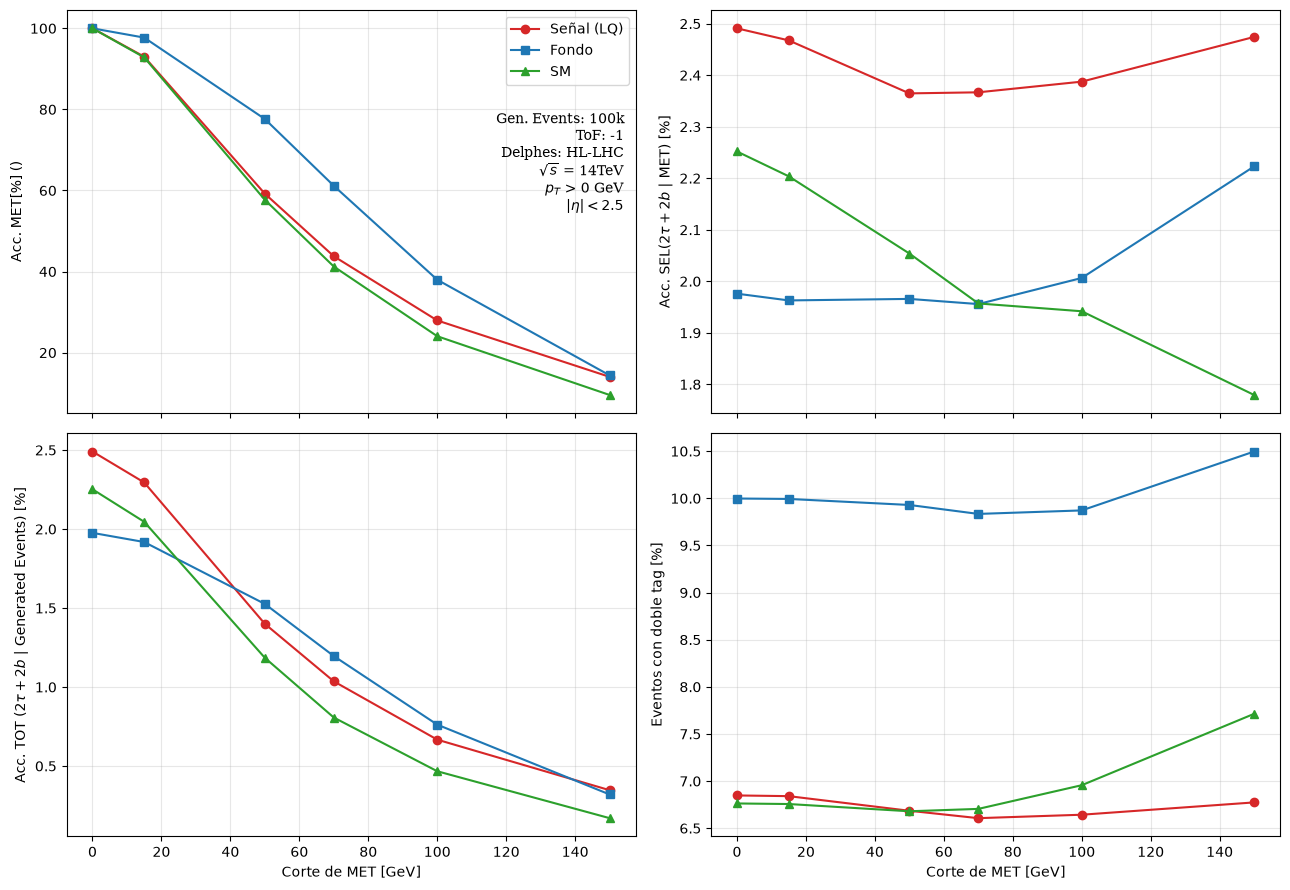

In [38]:
etiquetas = ["Señal (LQ)", "Fondo", "SM"]
colores   = ["tab:red", "tab:blue", "tab:green"]
marcas    = ["o", "s", "^"]

acc_MET = np.array(list_MET_acc)
acc_SEL = np.array(list_SEL_acc)
acc_TOT = np.array(list_TOT_acc)
dbl     = np.array(list_doubletag)

paneles = [
    (acc_MET, "Acc. MET[%] ()"),
    (acc_SEL, r"Acc. SEL($2\tau + 2b$ | MET) [%]"),
    (acc_TOT, r"Acc. TOT ($2\tau + 2b$ | Generated Events) [%]"),
    (dbl,     "Eventos con doble tag [%]"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for ax, (datos, ylabel) in zip(axes.flat, paneles):
    for i, (lab, col, mk) in enumerate(zip(etiquetas, colores, marcas)):
        ax.plot(MET_trigger_list, datos[:, i], marker=mk, color=col, label=lab)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Corte de MET [GeV]")

axes[0,0].text(0.98, 0.75, Jets_ID, transform=axes[0,0].transAxes,
    ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[0, 0].legend()

fig.tight_layout()
fig.savefig(f"{folder_path}/Aceptancias_y_DobleTag_vs_MET.png", dpi=300)
plt.show()

In [39]:
plot_histograms(list_tracks_ntrk, MET_trigger_list, "Tracks/ntrk_vs_MET", "Number of Tracks", "Events", Tracks_ID, range=(0, 200), bins=200, show = False)
plot_histograms(list_tracks_d0, MET_trigger_list, "Tracks/d0_vs_MET", "D0 [mm]", "Events", Tracks_ID, range=(-6, 6), bins=50, yscale="log", show = False)
plot_histograms(list_tracks_dz, MET_trigger_list, "Tracks/dz_vs_MET", "Dz [mm]", "Events", Tracks_ID, range=(-30,30), bins=50, yscale="log", show = False)
plot_histograms(list_tracks_pt, MET_trigger_list, "Tracks/Tracks_pt_vs_MET", "$p_T$ [GeV]", "Events", Tracks_ID, range=(0, 20), bins=50, show = False)

In [40]:
rango = [[-5,5], [-4, 4]]
figure_tag = ['Signal (LQ)', r'BG (tth)', 'SM']
colormaps = ['spring', 'winter', 'cool']

for index_figure in range(3):

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

    for ax, met, tup_eta, tup_phi in zip(axes.flat, MET_trigger_list,
                                    list_tracks_eta, list_tracks_phi):
        x = ak.to_numpy(tup_eta[index_figure])
        y = ak.to_numpy(tup_phi[index_figure])
        h = ax.hist2d(x, y, bins=50, range=rango,
                    cmap=colormaps[index_figure], cmin=1)
        ax.set_title(f"MET > {met} GeV", fontsize=11)
        ax.text(0.3, 0.97, f"N = {len(x)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="white")
        ax.text(0.98, 0.97, Tracks_ID, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, family="DejaVu Serif", color="white")
        ax.set_facecolor("black")

    for ax in axes[-1, :]:
        ax.set_xlabel(r"$\eta$", fontsize=13)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$\phi$", fontsize=13)

    fig.colorbar(h[3], ax=axes, label=f"Eventos de {figure_tag[index_figure]}", fraction=0.025, pad=0.02)

    fig.savefig(f"{folder_path}/Tracks/2D-EtaPhi_vs_MET-{figure_tag[index_figure]}.png", dpi=300)
    plt.close()

In [41]:
plot_histograms(list_InvarianMass, MET_trigger_list, "Jets/InvMass_vs_MET", "Invariant Mass [GeV]", "Events", Jets_ID, range=(130,1500), bins=40, show = False)

plot_2D_histograms(list_DeltaR_tautau, list_DeltaR_bb, MET_trigger_list,
                   rango_bidimensional=[[0, 6], [0, 6]],
                   jet_or_track="Jets",
                   xlabel=r"$\Delta R(\tau_{\rm vis},\tau_{\rm vis})$",
                   ylabel=r"$\Delta R(b,\bar{b})$", ID_tag = Jets_ID, show = False)

# PT Trigger

In [42]:
# Data Setting

PRE_MET_preselected = 0    # GeV
PRE_PTS_jets= 20       # GeV
PRE_Eta_jets= 2.5

PRE_PTS_tracks= 20       # GeV
PRE_Eta_tracks= 2.5

ID_Jets_ptcut = (fr"Delphes: {Delphes}, " r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                fr"MET > {PRE_MET_preselected} GeV" "\n"
                fr"pre-select $p_T$ > {PRE_PTS_jets} GeV" "\n"
                rf"pre-select $|\eta| < {PRE_Eta_jets}$")

# Seleccion de Jets y Tracks con Met

jets_sl, tracks_sl = Selected_data(data_sl, PRE_MET_preselected, PRE_PTS_jets, PRE_Eta_jets, PRE_PTS_tracks, PRE_Eta_tracks)
jets_bg, tracks_bg = Selected_data(data_bg, PRE_MET_preselected, PRE_PTS_jets, PRE_Eta_jets, PRE_PTS_tracks, PRE_Eta_tracks)
jets_sm, tracks_sm = Selected_data(data_sm, PRE_MET_preselected, PRE_PTS_jets, PRE_Eta_jets, PRE_PTS_tracks, PRE_Eta_tracks)

# Ahora separo en taus y bs

taus_sl, bjets_sl, N_events_sl = Taus_and_bjets(jets_sl)
taus_bg, bjets_bg, N_events_bg = Taus_and_bjets(jets_bg)
taus_sm, bjets_sm, N_events_sm = Taus_and_bjets(jets_sm)

# Selección de eventos con 2 taus y 2 b-jets

taus_cut_sl, bjets_cut_sl, lenght_taus_sl, lenght_bjets_sl = Particles_selection(taus_sl, bjets_sl)
taus_cut_bg, bjets_cut_bg, lenght_taus_bg, lenght_bjets_bg = Particles_selection(taus_bg, bjets_bg)
taus_cut_sm, bjets_cut_sm, lenght_taus_sm, lenght_bjets_sm = Particles_selection(taus_sm, bjets_sm)


In [43]:
def pt_combine_cut(taus, bjets, pt_bond):
    mask = (((taus[:,0]  + taus[:,1]).pt  > pt_bond[0]) &
            ((bjets[:,0] + bjets[:,1]).pt > pt_bond[1]))
    t, b = taus[mask], bjets[mask]
    return t[:,0], t[:,1], b[:,0], b[:,1]

In [44]:
# Recortes en Pt

# list_Pt_combine_LB = [0, 50, 80, 100, 150, 200] # GeV

list_Pt_combine_LB = [(0,0), (50,50), (80,80), (100,100), (150,150), (200,200)]

# Comienzo de bucle


list_PRE_acc = []
list_PT_acc = []
list_TOTPT_acc = []
list_mass_pt_cut = []
list_DeltaR_tautau_pt_cut = []
list_DeltaR_bb_pt_cut = []

for Pt_combine_LB in list_Pt_combine_LB:

    taus1_pt_selected_sl, taus2_pt_selected_sl, bjet1_pt_selected_sl, bjet2_pt_selected_sl = pt_combine_cut(taus_cut_sl,bjets_cut_sl, Pt_combine_LB)
    taus1_pt_selected_bg, taus2_pt_selected_bg, bjet1_pt_selected_bg, bjet2_pt_selected_bg = pt_combine_cut(taus_cut_bg,bjets_cut_bg, Pt_combine_LB)
    taus1_pt_selected_sm, taus2_pt_selected_sm, bjet1_pt_selected_sm, bjet2_pt_selected_sm = pt_combine_cut(taus_cut_sm,bjets_cut_sm, Pt_combine_LB)

    M_sl = (taus1_pt_selected_sl+taus2_pt_selected_sl+bjet1_pt_selected_sl+bjet2_pt_selected_sl).mass
    M_bg = (taus1_pt_selected_bg+taus2_pt_selected_bg+bjet1_pt_selected_bg+bjet2_pt_selected_bg).mass
    M_sm = (taus1_pt_selected_sm+taus2_pt_selected_sm+bjet1_pt_selected_sm+bjet2_pt_selected_sm).mass

    DR_sl_tautau = taus1_pt_selected_sl.deltaR(taus2_pt_selected_sl)
    DR_bg_tautau = taus1_pt_selected_bg.deltaR(taus2_pt_selected_bg)
    DR_sm_tautau = taus1_pt_selected_sm.deltaR(taus2_pt_selected_sm)

    DR_sl_bb = bjet1_pt_selected_sl.deltaR(bjet2_pt_selected_sl)
    DR_bg_bb = bjet1_pt_selected_bg.deltaR(bjet2_pt_selected_bg)
    DR_sm_bb = bjet1_pt_selected_sm.deltaR(bjet2_pt_selected_sm)

    # acc_preselection = acc_TOT = Eventos que pasan el filtro de preselección (MET, Pre-Pt, Pre-eta) y tienen mas de 2taus y 2bs sobre eventos generados
    # acc_pt = Eventos que pasan el filtro de pT sobre eventos preseleccionados (filtro de preseleccion y mas de 2taus y 2bs)
    # acc_pt_tot = Eventos que pasan la preseleccion y el filtro de PT por sobre el total de eventos generados

    acc_preselection_sl, acc_pt_sl, acc_totpt_sl = Acceptance(data_sl, taus_cut_sl, taus1_pt_selected_sl)
    acc_preselection_bg, acc_pt_bg, acc_totpt_bg = Acceptance(data_bg, taus_cut_bg, taus1_pt_selected_bg)
    acc_preselection_sm, acc_pt_sm, acc_totpt_sm = Acceptance(data_sm, taus_cut_sm, taus1_pt_selected_sm)

    Acc_PRE = (acc_preselection_sl, acc_preselection_bg, acc_preselection_sm)
    Acc_PT = (acc_pt_sl, acc_pt_bg, acc_pt_sm)
    Acc_TOTPT = (acc_totpt_sl, acc_totpt_bg, acc_totpt_sm)

    list_PRE_acc.append(Acc_PRE)
    list_PT_acc.append(Acc_PT)
    list_TOTPT_acc.append(Acc_TOTPT)

    list_mass_pt_cut.append((M_sl, M_bg, M_sm))
    list_DeltaR_tautau_pt_cut.append((DR_sl_tautau, DR_bg_tautau, DR_sm_tautau))
    list_DeltaR_bb_pt_cut.append((DR_sl_bb, DR_bg_bb, DR_sm_bb))

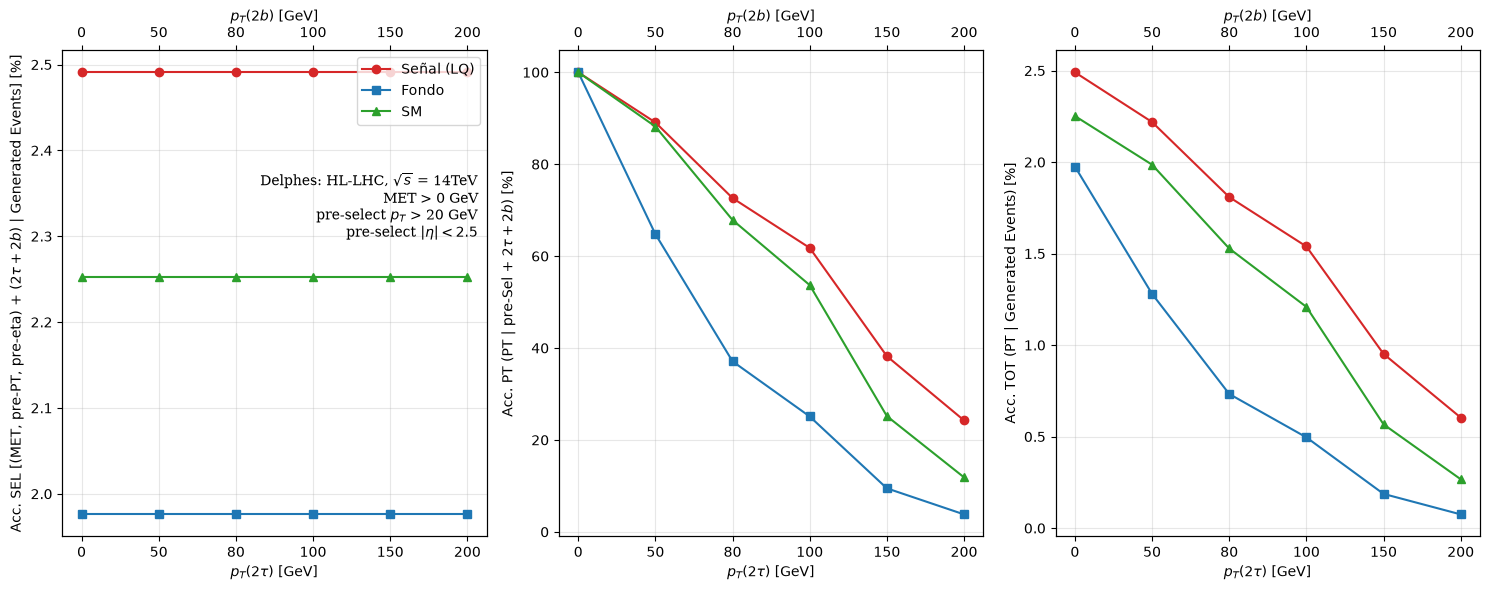

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=False)

acc_PRE = np.array(list_PRE_acc)
acc_PT = np.array(list_PT_acc)
acc_TOTPT = np.array(list_TOTPT_acc)

paneles = [
    (acc_PRE, r"Acc. SEL [(MET, pre-PT, pre-eta) + ($2\tau + 2b$) | Generated Events] [%]"),
    (acc_PT, r"Acc. PT (PT | pre-Sel + $2\tau + 2b$) [%]"),
    (acc_TOTPT, r"Acc. TOT (PT | Generated Events) [%]"),
]

pt_tau = np.array([x[0] for x in list_Pt_combine_LB])
pt_b = np.array([x[1] for x in list_Pt_combine_LB])

x = np.arange(len(list_Pt_combine_LB))

print()

for ax, (datos, ylabel) in zip(axes.flat, paneles):
    for i, (lab, col, mk) in enumerate(zip(etiquetas, colores, marcas)):
        ax.plot(x, datos[:, i], marker=mk, color=col, label=lab)

    ax.set_xticks(x)
    ax.set_xticklabels(pt_tau)
    ax.set_xlabel(r"$p_T(2\tau)$ [GeV]")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(pt_b)
    ax_top.set_xlabel(r"$p_T(2b)$ [GeV]")

axes[0].text(0.98, 0.75, ID_Jets_ptcut, transform=axes[0].transAxes,
    ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[0].legend()

fig.tight_layout()
fig.savefig(f"{folder_path}/Aceptancias_vs_PT.png", dpi=300)
plt.show()

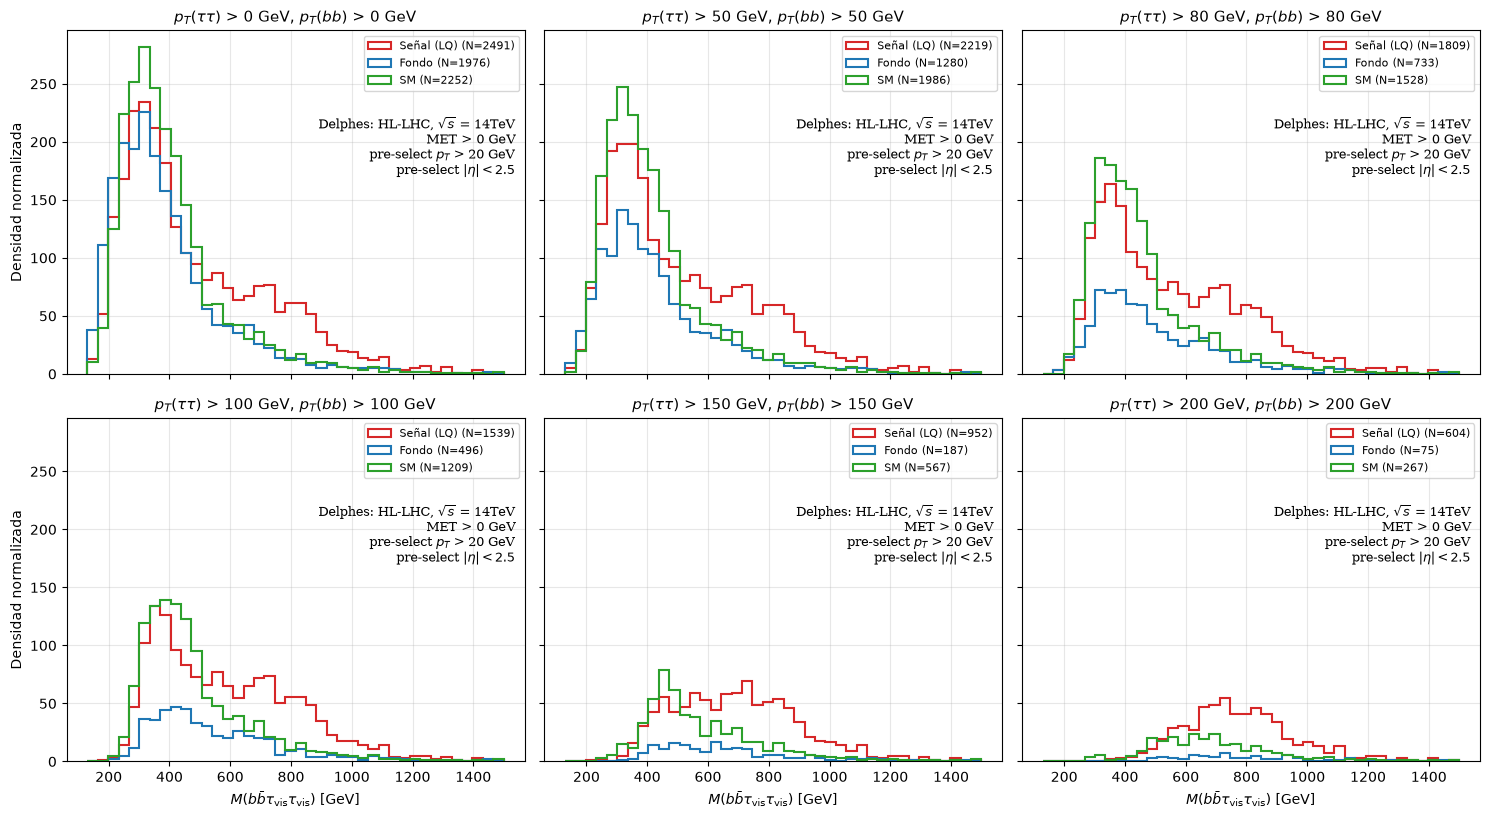

In [46]:
# Plot Masa invariante

etiquetas = ["Señal (LQ)", "Fondo", "SM"]
colores   = ["tab:red", "tab:blue", "tab:green"]
kw = dict(bins=40, range=(130, 1500), density=False, histtype="step", linewidth=1.5)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

for ax, pt_cut, tupla in zip(axes.flat, list_Pt_combine_LB, list_mass_pt_cut):
    for m, lab, col in zip(tupla, etiquetas, colores):
        ax.hist(ak.to_numpy(m), label=f"{lab} (N={len(m)})", color=col, **kw)
    ax.set_title(rf"$p_T(\tau \tau)$ > {pt_cut[0]} GeV, $p_T(bb)$ > {pt_cut[1]} GeV", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    ax.text(0.98, 0.75, ID_Jets_ptcut, transform=ax.transAxes,
        ha="right", va="top", fontsize=9, family="DejaVu Serif")

for ax in axes[-1, :]:
    ax.set_xlabel(r"$M(b\bar{b}\tau_{\rm vis}\tau_{\rm vis})$ [GeV]")
for ax in axes[:, 0]:
    ax.set_ylabel("Densidad normalizada")

fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(f"{folder_path}/Jets/InvMass_vs_PtCut.png", dpi=300)
plt.show()

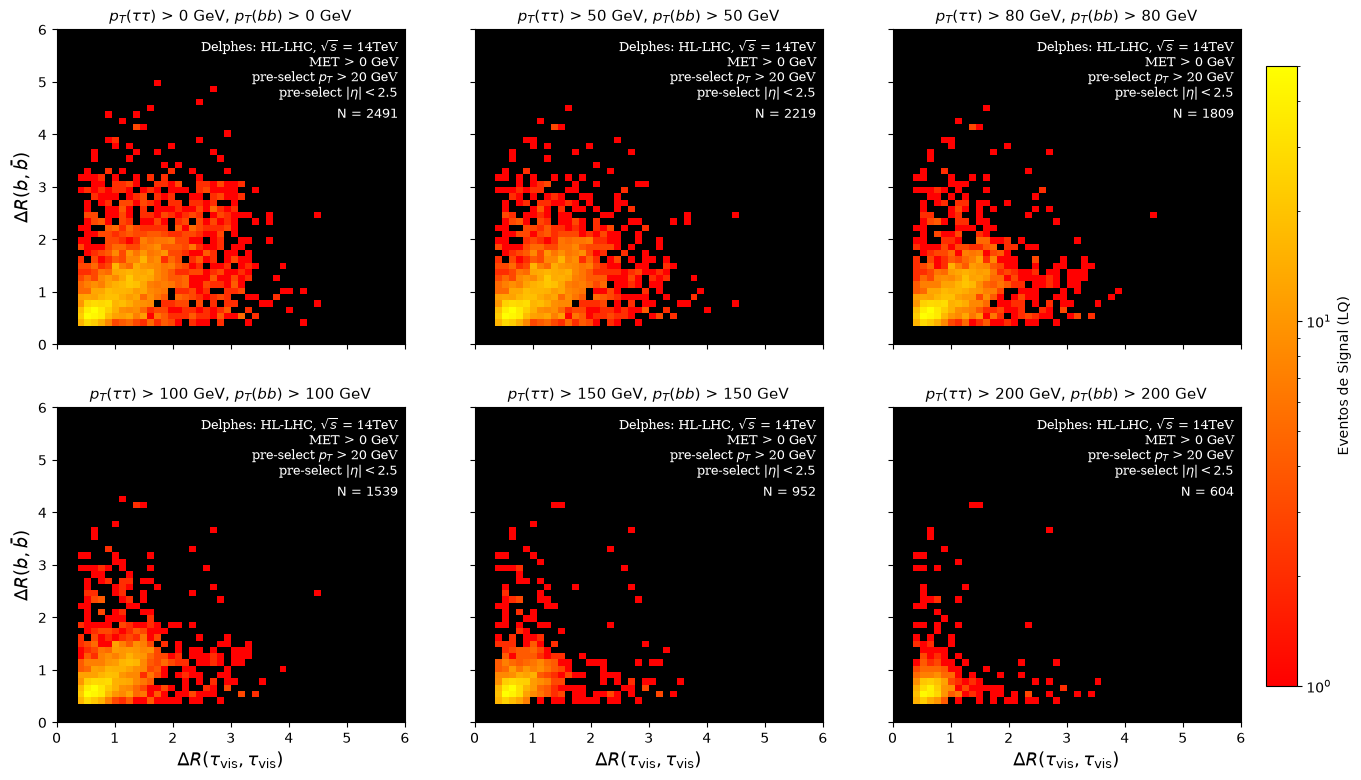

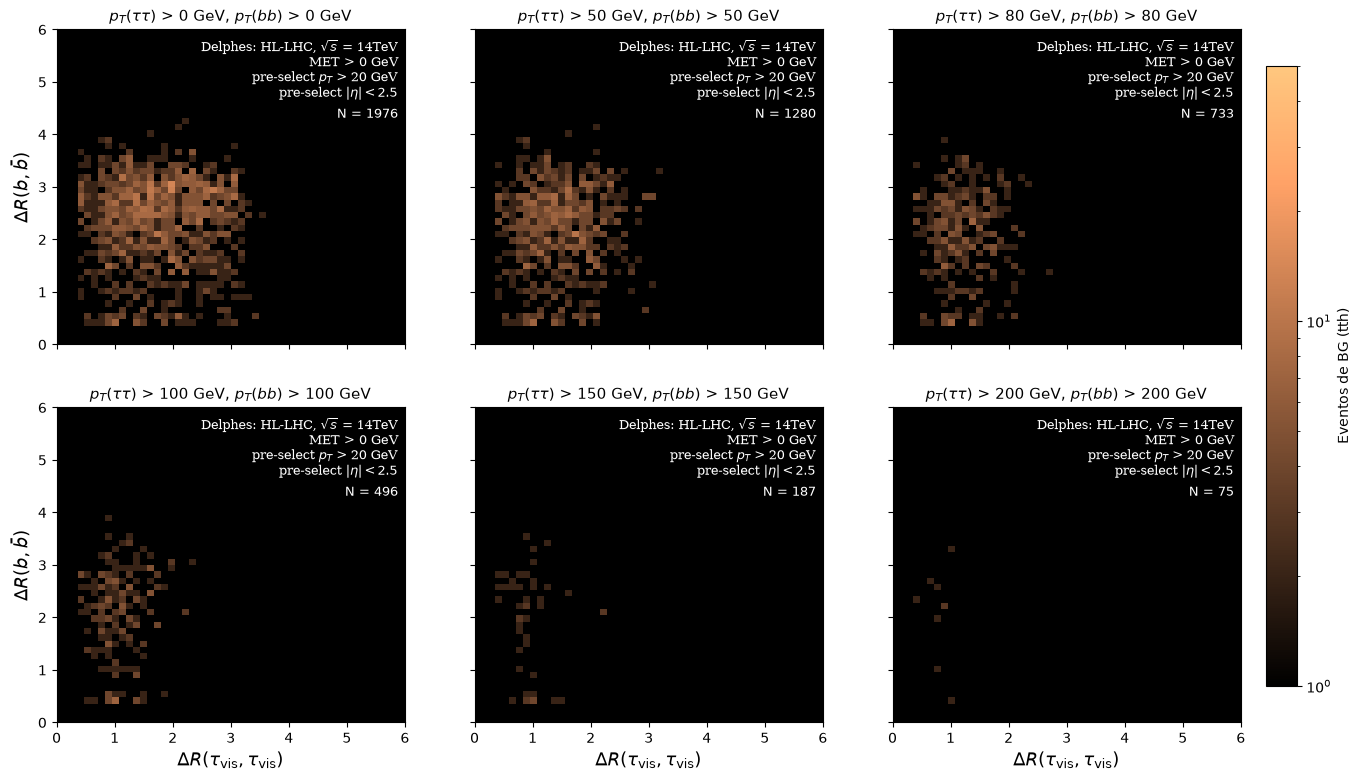

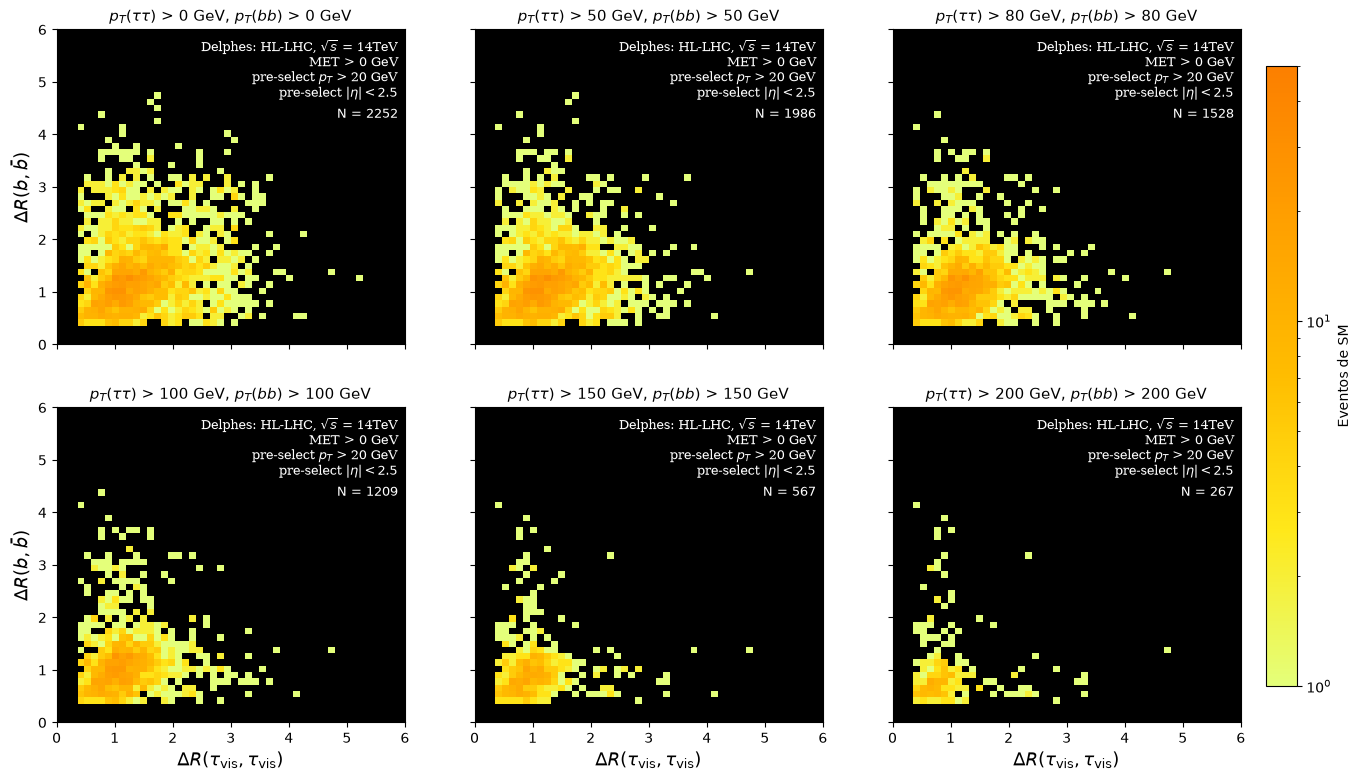

In [47]:
rango = [[0, 6], [0, 6]]
norm  = LogNorm(vmin=1, vmax=50)
figure_tag = ['Signal (LQ)', r'BG (tth)', 'SM']
colormaps = ['autumn', 'copper', 'Wistia']

for index_figure in range(3):

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

    for ax, pt, tup_tt, tup_bb in zip(axes.flat, list_Pt_combine_LB,
                                    list_DeltaR_tautau_pt_cut, list_DeltaR_bb_pt_cut):
        x = ak.to_numpy(tup_tt[index_figure])
        y = ak.to_numpy(tup_bb[index_figure])
        h = ax.hist2d(x, y, bins=50, range=rango,
                    cmap=colormaps[index_figure], norm=norm, cmin=1)
        ax.set_title(fr"$p_T(\tau \tau)$ > {pt[0]} GeV, $p_T(bb)$ > {pt[1]} GeV", fontsize=11)
        ax.text(0.98, 0.75, f"N = {len(x)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="white")
        ax.text(0.98, 0.97, ID_Jets_ptcut, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, family="DejaVu Serif", color="white")
        ax.set_facecolor("black")

    for ax in axes[-1, :]:
        ax.set_xlabel(r"$\Delta R(\tau_{\rm vis},\tau_{\rm vis})$", fontsize=13)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$\Delta R(b,\bar{b})$", fontsize=13)

    fig.colorbar(h[3], ax=axes, label=f"Eventos de {figure_tag[index_figure]}", fraction=0.025, pad=0.02)

    fig.savefig(f"{folder_path}/Jets/2D-DeltaR_vs_PT-{figure_tag[index_figure]}.png", dpi=300)
    plt.show()
